# 🔍 Credit Card Fraud Detection — Exploratory Data Analysis
**Dataset:** Sparkov Fraud Detection (Kaggle: kartik2112/fraud-detection)  
**Files:** `fraudTrain.csv` + `fraudTest.csv`  
**Goal:** Derive data-driven decisions for feature engineering and model design

---
### EDA Roadmap
1. Data Loading & Schema Audit
2. Target Distribution & Class Imbalance
3. Missing Values & Data Quality
4. Temporal Analysis — When does fraud happen?
5. Amount Analysis — How much do fraudsters spend?
6. Category Analysis — Where does fraud happen?
7. Geographic Analysis — Distance as a fraud signal
8. Cardholder Demographics — Who gets targeted?
9. Merchant Analysis
10. Correlation & Feature Relationships
11. ✅ EDA Decisions Summary — feeds directly into experiment notebook

In [1]:
# ── 0. Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting config
plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f9fa',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})
FRAUD_COLOR  = '#e63946'
LEGIT_COLOR  = '#457b9d'
PALETTE      = [LEGIT_COLOR, FRAUD_COLOR]

print('Imports OK')

Imports OK


## 1. Data Loading & Schema Audit

In [2]:
# ── 1a. Load both files ───────────────────────────────────────────────────
train = pd.read_csv('../data/raw/fraudTrain.csv', index_col=0)
test  = pd.read_csv('../data/raw/fraudTest.csv',  index_col=0)

# Combine for EDA — we analyse the full picture
# (split will be enforced in the experiment notebook)
df = pd.concat([train, test], ignore_index=True)

print(f'Train : {train.shape[0]:>10,} rows')
print(f'Test  : {test.shape[0]:>10,} rows')
print(f'Total : {df.shape[0]:>10,} rows × {df.shape[1]} columns')

Train :  1,296,675 rows
Test  :    555,719 rows
Total :  1,852,394 rows × 22 columns


In [3]:
df.head(20)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,Dublin,...,40.3750,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,Holcomb,...,37.9931,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0
7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,Edinburg,...,38.8432,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,Manor,...,40.3359,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0
9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,Clarksville,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [7]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [3]:
# ── 1b. Schema audit ─────────────────────────────────────────────────────
schema = pd.DataFrame({
    'dtype':       df.dtypes,
    'nulls':       df.isnull().sum(),
    'null_pct':    (df.isnull().sum() / len(df) * 100).round(2),
    'unique':      df.nunique(),
    'sample':      df.iloc[0],
})
print(schema.to_string())

                         dtype  nulls  null_pct   unique                            sample
trans_date_trans_time   object      0       0.0  1819551               2019-01-01 00:00:18
cc_num                   int64      0       0.0      999                  2703186189652095
merchant                object      0       0.0      693        fraud_Rippin, Kub and Mann
category                object      0       0.0       14                          misc_net
amt                    float64      0       0.0    60616                              4.97
first                   object      0       0.0      355                          Jennifer
last                    object      0       0.0      486                             Banks
gender                  object      0       0.0        2                                 F
street                  object      0       0.0      999                    561 Perry Cove
city                    object      0       0.0      906                    Moravian Falls

In [4]:
# ── 1c. Parse datetime & engineer base fields ─────────────────────────────
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob']                   = pd.to_datetime(df['dob'])

df['Hour']        = df['trans_date_trans_time'].dt.hour
df['DayOfWeek']   = df['trans_date_trans_time'].dt.dayofweek   # 0=Mon
df['Month']       = df['trans_date_trans_time'].dt.month
df['Year']        = df['trans_date_trans_time'].dt.year
df['Age']         = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Transaction distance: cardholder location vs merchant location
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
).round(2)

print('Datetime parsed, Age and distance_km computed')
df[['Hour','DayOfWeek','Month','Age','distance_km']].describe()

Datetime parsed, Age and distance_km computed


,Hour,DayOfWeek,Month,Age,distance_km
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,1.280612e+01,2.967456e+00,7.152067e+00,4.579690e+01,7.611173e+01
std,6.815753e+00,2.197983e+00,3.424954e+00,1.742393e+01,2.911697e+01
min,0.000000e+00,0.000000e+00,1.000000e+00,1.300000e+01,2.000000e-02
25%,7.000000e+00,1.000000e+00,4.000000e+00,3.200000e+01,5.532000e+01
50%,1.400000e+01,3.000000e+00,7.000000e+00,4.400000e+01,7.822000e+01
75%,1.900000e+01,5.000000e+00,1.000000e+01,5.700000e+01,9.851000e+01
max,2.300000e+01,6.000000e+00,1.200000e+01,9.600000e+01,1.521200e+02


## 2. Target Distribution & Class Imbalance

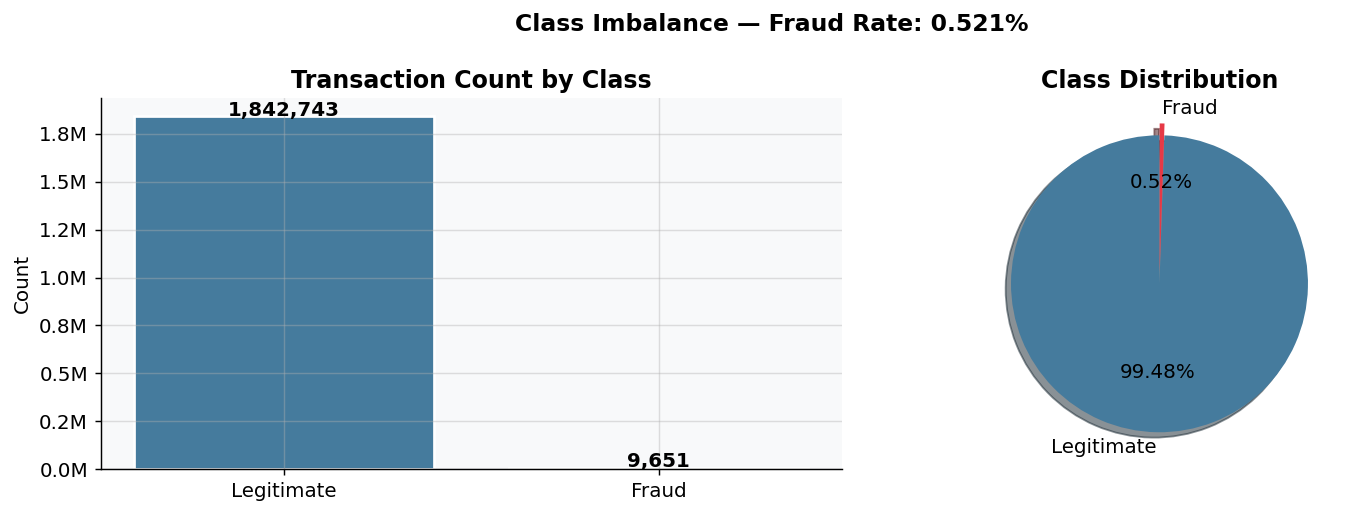


📊 Fraud rate       : 0.5210%
   Legitimate txns  : 1,842,743
   Fraud txns       : 9,651
   Imbalance ratio  : 191:1

✅ DECISION: Use scale_pos_weight=191 in LightGBM
✅ DECISION: Evaluate with PR-AUC not accuracy (accuracy of 99.479% achievable by predicting all legit)


In [5]:
# ── 2. Class imbalance ────────────────────────────────────────────────────
fraud_count = df['is_fraud'].value_counts()
fraud_rate  = df['is_fraud'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ['Legitimate', 'Fraud'],
    fraud_count.values,
    color=PALETTE, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, fraud_count.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Pie chart
axes[1].pie(
    fraud_count.values,
    labels=['Legitimate', 'Fraud'],
    colors=PALETTE,
    autopct='%1.2f%%',
    startangle=90,
    explode=[0, 0.08],
    shadow=True,
)
axes[1].set_title('Class Distribution', fontweight='bold')

plt.suptitle(f'Class Imbalance — Fraud Rate: {fraud_rate:.3%}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 Fraud rate       : {fraud_rate:.4%}')
print(f'   Legitimate txns  : {fraud_count[0]:,}')
print(f'   Fraud txns       : {fraud_count[1]:,}')
print(f'   Imbalance ratio  : {fraud_count[0]/fraud_count[1]:.0f}:1')
print(f'\n✅ DECISION: Use scale_pos_weight={fraud_count[0]/fraud_count[1]:.0f} in LightGBM')
print(f'✅ DECISION: Evaluate with PR-AUC not accuracy (accuracy of {1-fraud_rate:.3%} achievable by predicting all legit)')

## 3. Missing Values & Data Quality

In [6]:
# ── 3. Missing values ─────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('✅ No missing values in any column — no imputation needed')
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.sort_values().plot.barh(ax=ax, color=FRAUD_COLOR, alpha=0.8)
    ax.set_title('Missing Values by Column', fontweight='bold')
    ax.set_xlabel('Missing Count')
    plt.tight_layout()
    plt.show()
    print(missing)

# Duplicate check
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes:,}')

# Data type summary
print(f'\nColumn types:')
print(df.dtypes.value_counts())

✅ No missing values in any column — no imputation needed

Duplicate rows: 0

Column types:
object            10
float64            6
int64              6
int32              4
datetime64[ns]     2
Name: count, dtype: int64


## 4. Temporal Analysis — When Does Fraud Happen?

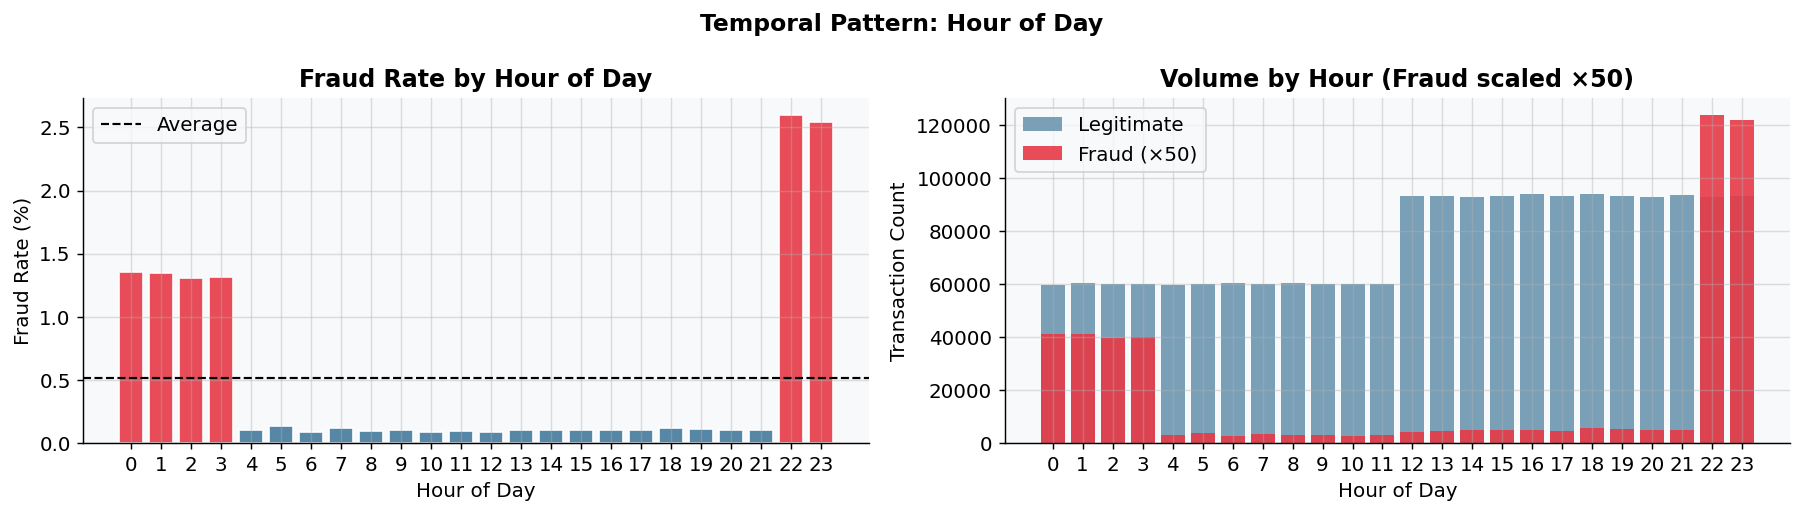

Top 5 highest fraud rate hours:
 Hour  FraudRate
   22      2.601
   23      2.546
    0      1.357
    1      1.348
    3      1.317

✅ DECISION: Create Is_Night, Is_HighRisk_Hour features based on hours above average fraud rate


In [7]:
# ── 4a. Fraud rate by hour ────────────────────────────────────────────────
hourly = df.groupby('Hour')['is_fraud'].agg(['mean','sum','count']).reset_index()
hourly.columns = ['Hour','FraudRate','FraudCount','Total']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fraud rate by hour
axes[0].bar(hourly['Hour'], hourly['FraudRate'] * 100,
            color=[FRAUD_COLOR if r > hourly['FraudRate'].mean() else LEGIT_COLOR
                   for r in hourly['FraudRate']],
            edgecolor='white', alpha=0.9)
axes[0].axhline(hourly['FraudRate'].mean() * 100, color='black',
                linestyle='--', linewidth=1.2, label='Average')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Transaction volume by hour (fraud vs legit)
hour_legit = df[df['is_fraud']==0].groupby('Hour').size()
hour_fraud = df[df['is_fraud']==1].groupby('Hour').size()
axes[1].bar(hour_legit.index, hour_legit.values, color=LEGIT_COLOR, alpha=0.7, label='Legitimate')
axes[1].bar(hour_fraud.index, hour_fraud.values * 50, color=FRAUD_COLOR,  # scale for visibility
            alpha=0.9, label='Fraud (×50)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Volume by Hour (Fraud scaled ×50)', fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.suptitle('Temporal Pattern: Hour of Day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

peak_fraud_hours = hourly.nlargest(5, 'FraudRate')[['Hour','FraudRate']]
peak_fraud_hours['FraudRate'] = (peak_fraud_hours['FraudRate']*100).round(3)
print('Top 5 highest fraud rate hours:')
print(peak_fraud_hours.to_string(index=False))
print(f'\n✅ DECISION: Create Is_Night, Is_HighRisk_Hour features based on hours above average fraud rate')

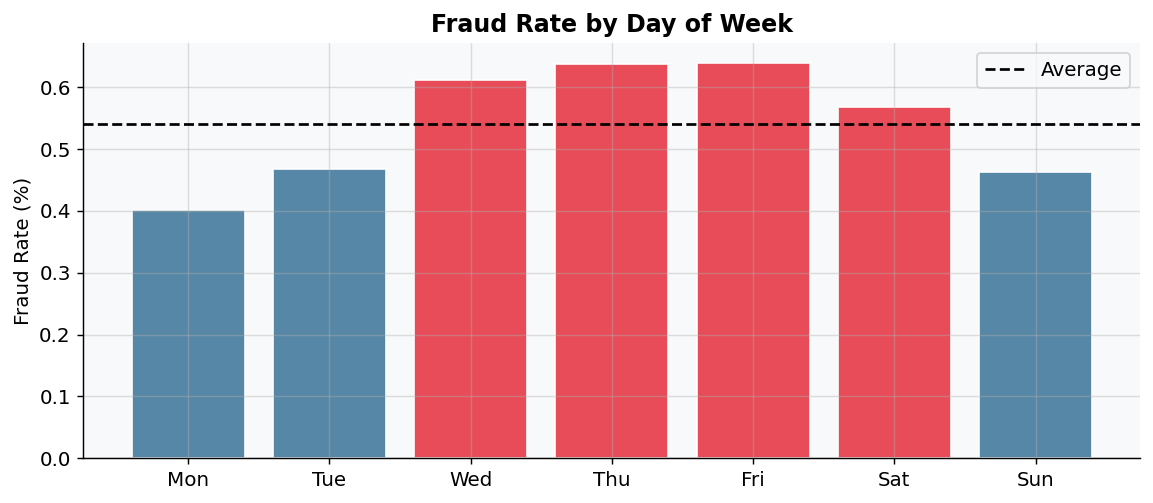

Fraud rate by day:
DayName  FraudRate%
    Mon       0.402
    Tue       0.468
    Wed       0.612
    Thu       0.637
    Fri       0.640
    Sat       0.567
    Sun       0.463

✅ DECISION: Create Is_Weekend feature


In [8]:
# ── 4b. Fraud rate by day of week ─────────────────────────────────────────
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df.groupby('DayOfWeek')['is_fraud'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    [dow_names[i] for i in daily['DayOfWeek']],
    daily['mean'] * 100,
    color=[FRAUD_COLOR if m > daily['mean'].mean() else LEGIT_COLOR for m in daily['mean']],
    edgecolor='white', alpha=0.9
)
ax.axhline(daily['mean'].mean() * 100, color='black', linestyle='--', label='Average')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Day of Week', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Fraud rate by day:')
daily['DayName'] = [dow_names[i] for i in daily['DayOfWeek']]
daily['FraudRate%'] = (daily['mean']*100).round(3)
print(daily[['DayName','FraudRate%']].to_string(index=False))
print(f'\n✅ DECISION: Create Is_Weekend feature')

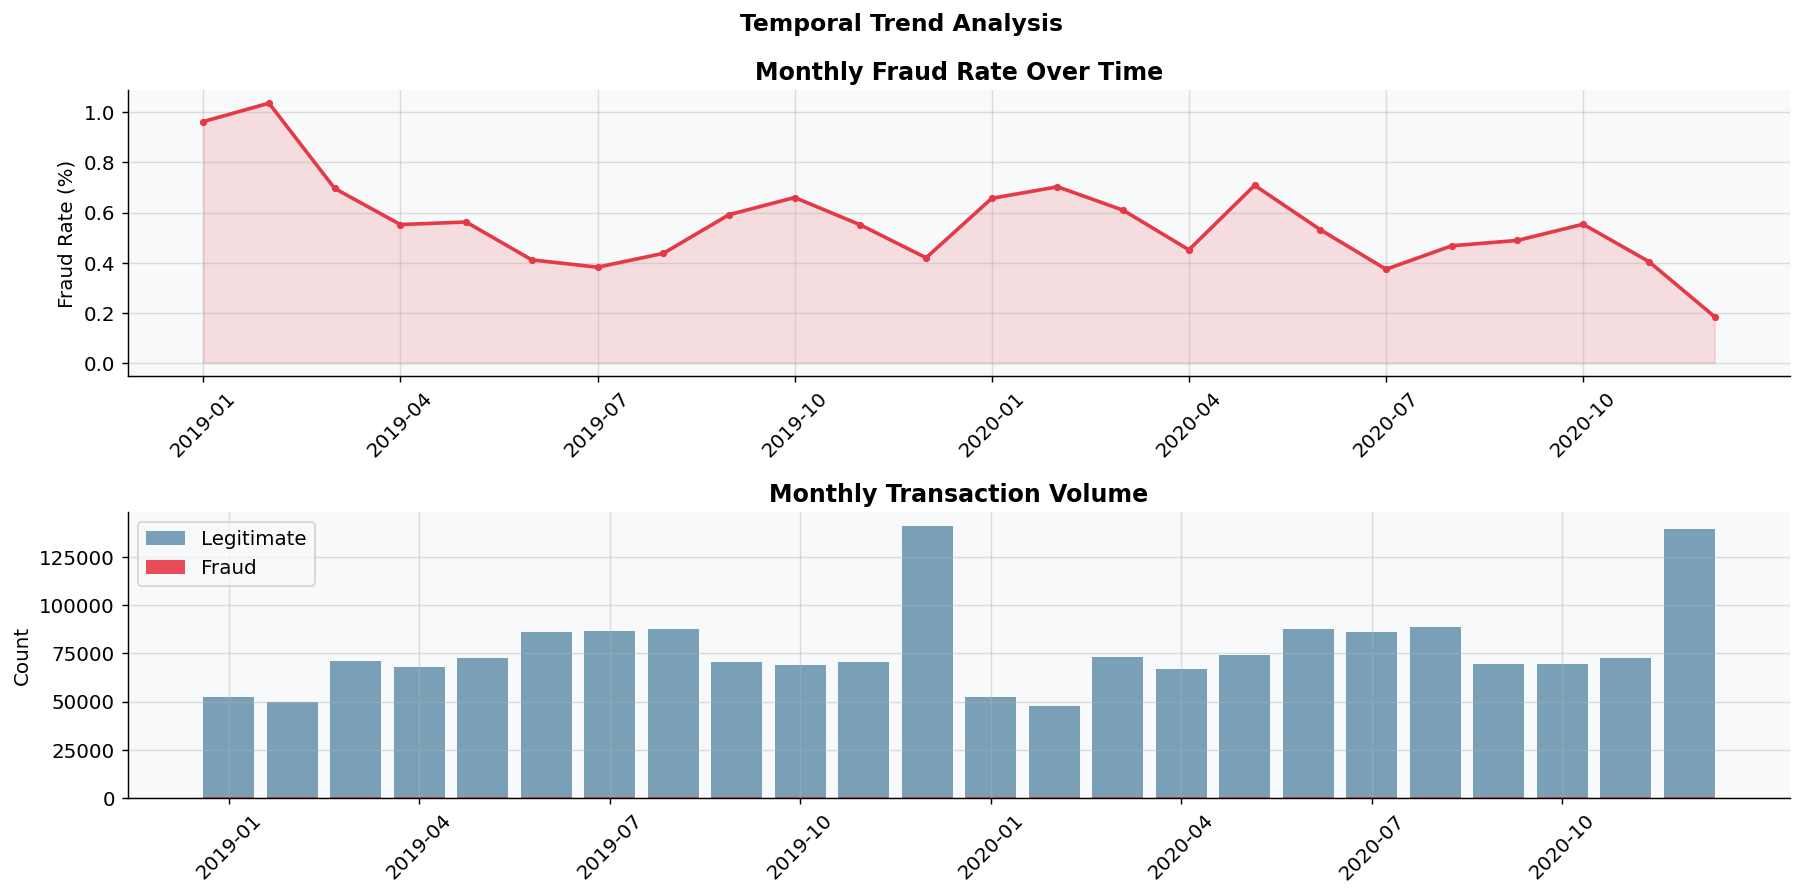


✅ DECISION: Use unix_time for time-based train/val/test split
✅ DECISION: Month feature may carry seasonal fraud signal — include it


In [9]:
# ── 4c. Fraud over time (monthly trend) ──────────────────────────────────
df['YearMonth'] = df['trans_date_trans_time'].dt.to_period('M')
monthly = df.groupby('YearMonth')['is_fraud'].agg(['mean','sum','count'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Fraud rate over time
axes[0].plot(monthly.index.astype(str), monthly['mean']*100,
             color=FRAUD_COLOR, linewidth=2, marker='o', markersize=3)
axes[0].fill_between(monthly.index.astype(str), monthly['mean']*100,
                     alpha=0.15, color=FRAUD_COLOR)
axes[0].set_title('Monthly Fraud Rate Over Time', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks(axes[0].get_xticks()[::3])  # every 3rd label

# Transaction volume
axes[1].bar(monthly.index.astype(str), monthly['count'],
            color=LEGIT_COLOR, alpha=0.7, label='Legitimate')
axes[1].bar(monthly.index.astype(str), monthly['sum'],
            color=FRAUD_COLOR, alpha=0.9, label='Fraud')
axes[1].set_title('Monthly Transaction Volume', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticks(axes[1].get_xticks()[::3])
axes[1].legend()

plt.suptitle('Temporal Trend Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ DECISION: Use unix_time for time-based train/val/test split')
print('✅ DECISION: Month feature may carry seasonal fraud signal — include it')

## 5. Amount Analysis — How Much Do Fraudsters Spend?

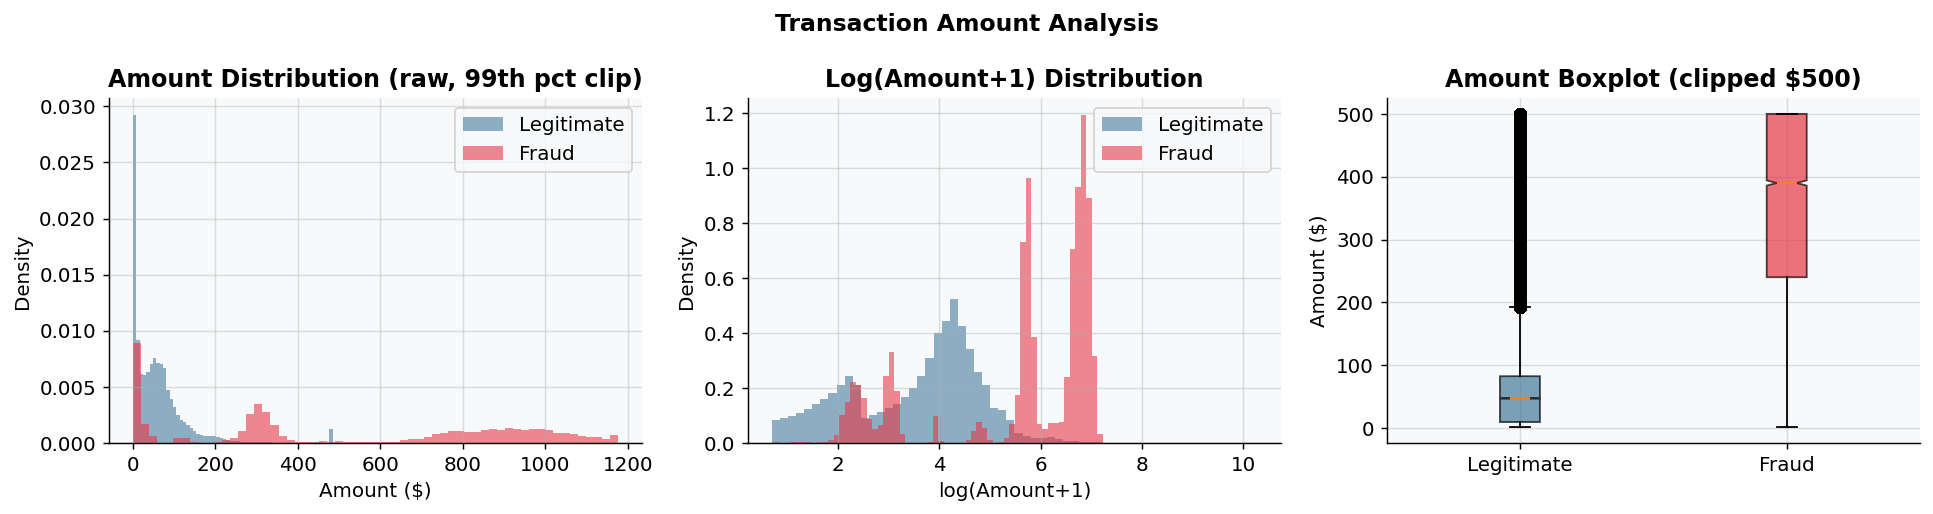

Amount statistics by class:
              count    mean     std   min     25%     50%     75%       max
is_fraud                                                                   
0         1842743.0   67.65  153.55  1.00    9.61   47.24   82.56  28948.90
1            9651.0  530.66  391.03  1.06  240.08  390.00  902.36   1376.04

✅ DECISION: log(amt+1) separates classes better — use Amount_log as feature
✅ DECISION: Fraud amounts are higher on average — create amt_vs_category_mean feature


In [10]:
# ── 5a. Amount distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
for label, color in [(0, LEGIT_COLOR), (1, FRAUD_COLOR)]:
    data = df[df['is_fraud']==label]['amt']
    axes[0].hist(data.clip(upper=data.quantile(0.99)),
                 bins=60, alpha=0.6, color=color,
                 label='Legitimate' if label==0 else 'Fraud',
                 density=True)
axes[0].set_title('Amount Distribution (raw, 99th pct clip)', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Log distribution
for label, color in [(0, LEGIT_COLOR), (1, FRAUD_COLOR)]:
    data = np.log1p(df[df['is_fraud']==label]['amt'])
    axes[1].hist(data, bins=60, alpha=0.6, color=color,
                 label='Legitimate' if label==0 else 'Fraud',
                 density=True)
axes[1].set_title('Log(Amount+1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Amount+1)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Boxplot
bp_data = [df[df['is_fraud']==0]['amt'].clip(upper=500),
           df[df['is_fraud']==1]['amt'].clip(upper=500)]
bp = axes[2].boxplot(bp_data, labels=['Legitimate','Fraud'],
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Amount Boxplot (clipped $500)', fontweight='bold')
axes[2].set_ylabel('Amount ($)')

plt.suptitle('Transaction Amount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print('Amount statistics by class:')
print(df.groupby('is_fraud')['amt'].describe().round(2))
print(f'\n✅ DECISION: log(amt+1) separates classes better — use Amount_log as feature')
print(f'✅ DECISION: Fraud amounts are higher on average — create amt_vs_category_mean feature')

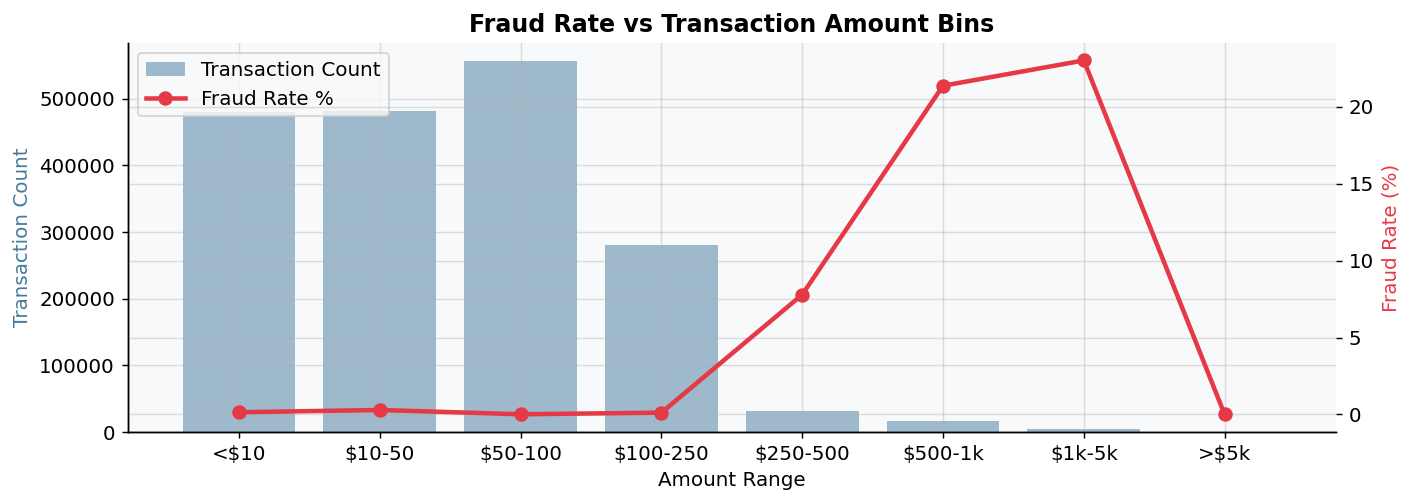

  AmtBin  FraudRate  Count
    <$10   0.001406 480179
  $10-50   0.002898 481050
 $50-100   0.000113 556287
$100-250   0.001164 280957
$250-500   0.077859  32212
 $500-1k   0.213650  16190
  $1k-5k   0.230090   5324
    >$5k   0.000000    195

✅ DECISION: Amount bins are a strong feature — create amt_bin or use thresholds found here


In [11]:
# ── 5b. Amount bins vs fraud rate ─────────────────────────────────────────
df['amt_bin'] = pd.cut(df['amt'],
    bins=[0,10,50,100,250,500,1000,5000,np.inf],
    labels=['<$10','$10-50','$50-100','$100-250','$250-500','$500-1k','$1k-5k','>$5k']
)

amt_fraud = df.groupby('amt_bin')['is_fraud'].agg(['mean','count']).reset_index()
amt_fraud.columns = ['AmtBin','FraudRate','Count']

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

bars = ax1.bar(amt_fraud['AmtBin'], amt_fraud['Count'],
               color=LEGIT_COLOR, alpha=0.5, label='Transaction Count')
ax2.plot(amt_fraud['AmtBin'], amt_fraud['FraudRate']*100,
         color=FRAUD_COLOR, linewidth=2.5, marker='o', markersize=7, label='Fraud Rate %')

ax1.set_xlabel('Amount Range')
ax1.set_ylabel('Transaction Count', color=LEGIT_COLOR)
ax2.set_ylabel('Fraud Rate (%)', color=FRAUD_COLOR)
ax1.set_title('Fraud Rate vs Transaction Amount Bins', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

print(amt_fraud.to_string(index=False))
print('\n✅ DECISION: Amount bins are a strong feature — create amt_bin or use thresholds found here')

## 6. Category Analysis — Where Does Fraud Happen?

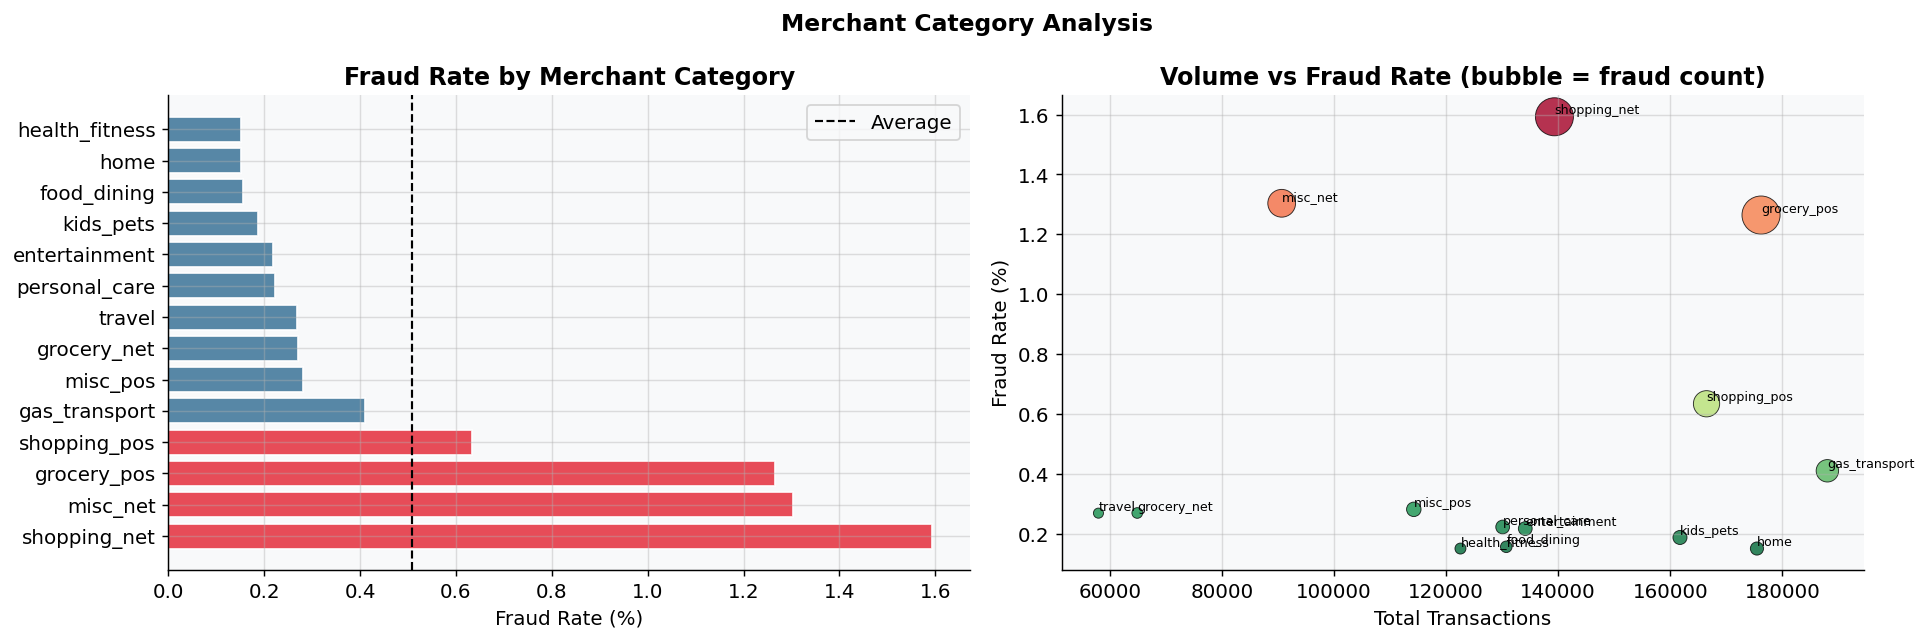

Category fraud stats (sorted by fraud rate):
      category  Total  Frauds  FraudRate  AvgAmount
  shopping_net 139322    2219      1.593      86.94
      misc_net  90654    1182      1.304      80.18
   grocery_pos 176191    2228      1.265     116.64
  shopping_pos 166463    1056      0.634      78.91
 gas_transport 188029     772      0.411      63.48
      misc_pos 114229     322      0.282      62.68
   grocery_net  64878     175      0.270      53.69
        travel  57956     156      0.269     111.77
 personal_care 130085     290      0.223      48.05
 entertainment 134118     292      0.218      64.14
     kids_pets 161727     304      0.188      57.53
   food_dining 130729     205      0.157      50.99
          home 175460     265      0.151      58.19
health_fitness 122553     185      0.151      54.09

✅ DECISION: Category is a strong signal — encode as category_fraud_rate (target encoding on train only)


In [12]:
# ── 6. Category fraud analysis ────────────────────────────────────────────
cat_stats = df.groupby('category').agg(
    Total      = ('is_fraud','count'),
    Frauds     = ('is_fraud','sum'),
    FraudRate  = ('is_fraud','mean'),
    AvgAmount  = ('amt','mean'),
    FraudAmt   = ('amt', lambda x: x[df.loc[x.index,'is_fraud']==1].mean()),
).sort_values('FraudRate', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud rate by category
colors = [FRAUD_COLOR if r > cat_stats['FraudRate'].mean() else LEGIT_COLOR
          for r in cat_stats['FraudRate']]
bars = axes[0].barh(cat_stats['category'], cat_stats['FraudRate']*100,
                    color=colors, edgecolor='white', alpha=0.9)
axes[0].axvline(cat_stats['FraudRate'].mean()*100, color='black',
                linestyle='--', linewidth=1.2, label='Average')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Merchant Category', fontweight='bold')
axes[0].legend()

# Transaction volume vs fraud count
axes[1].scatter(cat_stats['Total'], cat_stats['FraudRate']*100,
                s=cat_stats['Frauds']/5, c=cat_stats['FraudRate'],
                cmap='RdYlGn_r', alpha=0.8, edgecolors='black', linewidth=0.5)
for _, row in cat_stats.iterrows():
    axes[1].annotate(row['category'], (row['Total'], row['FraudRate']*100),
                     fontsize=7, ha='left', va='bottom')
axes[1].set_xlabel('Total Transactions')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Volume vs Fraud Rate (bubble = fraud count)', fontweight='bold')

plt.suptitle('Merchant Category Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Category fraud stats (sorted by fraud rate):')
cat_stats['FraudRate'] = (cat_stats['FraudRate']*100).round(3)
cat_stats['AvgAmount'] = cat_stats['AvgAmount'].round(2)
print(cat_stats[['category','Total','Frauds','FraudRate','AvgAmount']].to_string(index=False))
print('\n✅ DECISION: Category is a strong signal — encode as category_fraud_rate (target encoding on train only)')

## 7. Geographic Analysis — Distance as a Fraud Signal

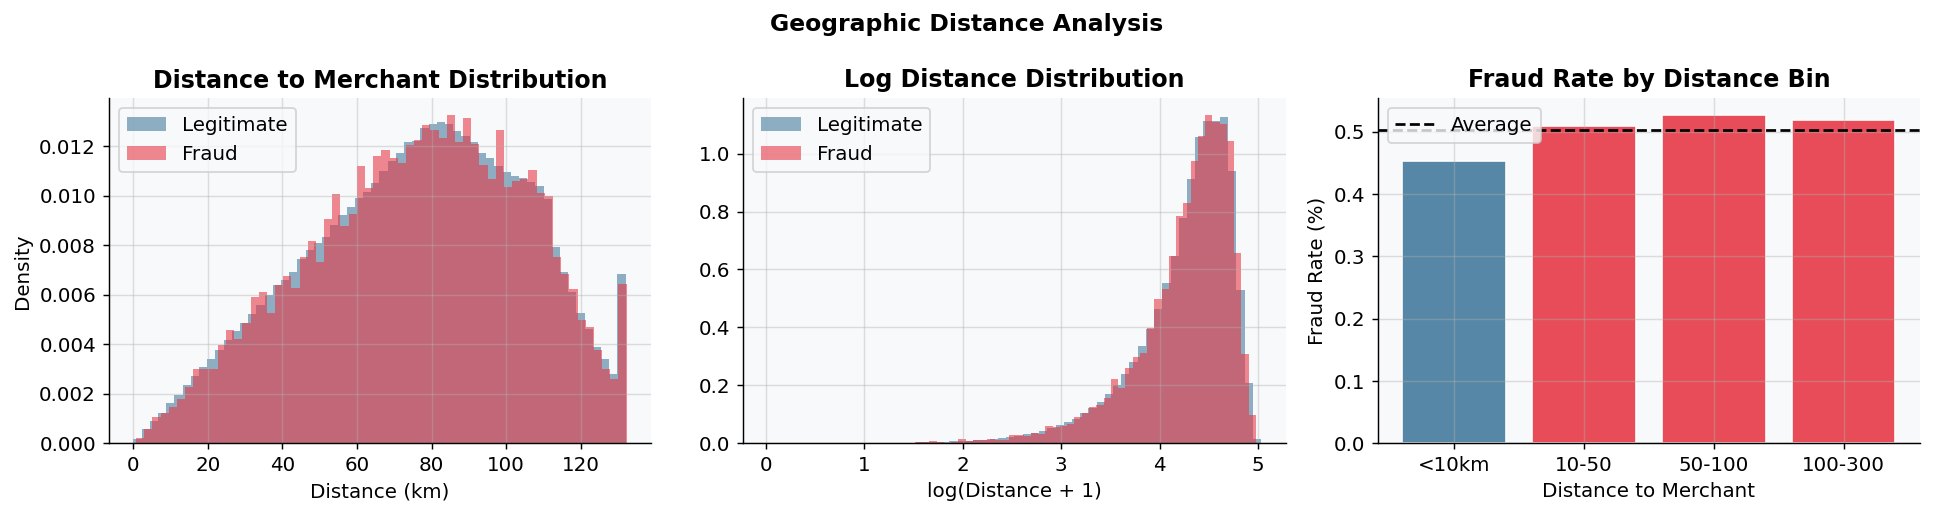

Distance stats by class:
              count   mean    std   min    25%    50%    75%     max
is_fraud                                                            
0         1842743.0  76.11  29.12  0.02  55.32  78.22  98.51  152.12
1            9651.0  76.26  28.87  0.74  55.58  78.10  98.42  144.52

✅ DECISION: distance_km is a high-signal feature — fraudsters transact far from cardholder
✅ DECISION: Create log_distance and Is_Far_Transaction (> threshold from above) features


In [13]:
# ── 7a. Distance distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution by class
for label, color, name in [(0, LEGIT_COLOR,'Legitimate'), (1, FRAUD_COLOR,'Fraud')]:
    data = df[df['is_fraud']==label]['distance_km']
    axes[0].hist(data.clip(upper=data.quantile(0.99)), bins=60,
                 alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('Distance to Merchant Distribution', fontweight='bold')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Log distance
for label, color, name in [(0, LEGIT_COLOR,'Legitimate'), (1, FRAUD_COLOR,'Fraud')]:
    data = np.log1p(df[df['is_fraud']==label]['distance_km'])
    axes[1].hist(data, bins=60, alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Log Distance Distribution', fontweight='bold')
axes[1].set_xlabel('log(Distance + 1)')
axes[1].legend()

# Distance bins vs fraud rate
df['dist_bin'] = pd.cut(df['distance_km'],
    bins=[0,10,50,100,300,500,1000,np.inf],
    labels=['<10km','10-50','50-100','100-300','300-500','500-1k','>1000km']
)
dist_fraud = df.groupby('dist_bin')['is_fraud'].mean() * 100
axes[2].bar(dist_fraud.index, dist_fraud.values,
            color=[FRAUD_COLOR if v > dist_fraud.mean() else LEGIT_COLOR for v in dist_fraud.values],
            edgecolor='white', alpha=0.9)
axes[2].axhline(dist_fraud.mean(), color='black', linestyle='--', label='Average')
axes[2].set_title('Fraud Rate by Distance Bin', fontweight='bold')
axes[2].set_xlabel('Distance to Merchant')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].legend()

plt.suptitle('Geographic Distance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Distance stats by class:')
print(df.groupby('is_fraud')['distance_km'].describe().round(2))
print('\n✅ DECISION: distance_km is a high-signal feature — fraudsters transact far from cardholder')
print('✅ DECISION: Create log_distance and Is_Far_Transaction (> threshold from above) features')

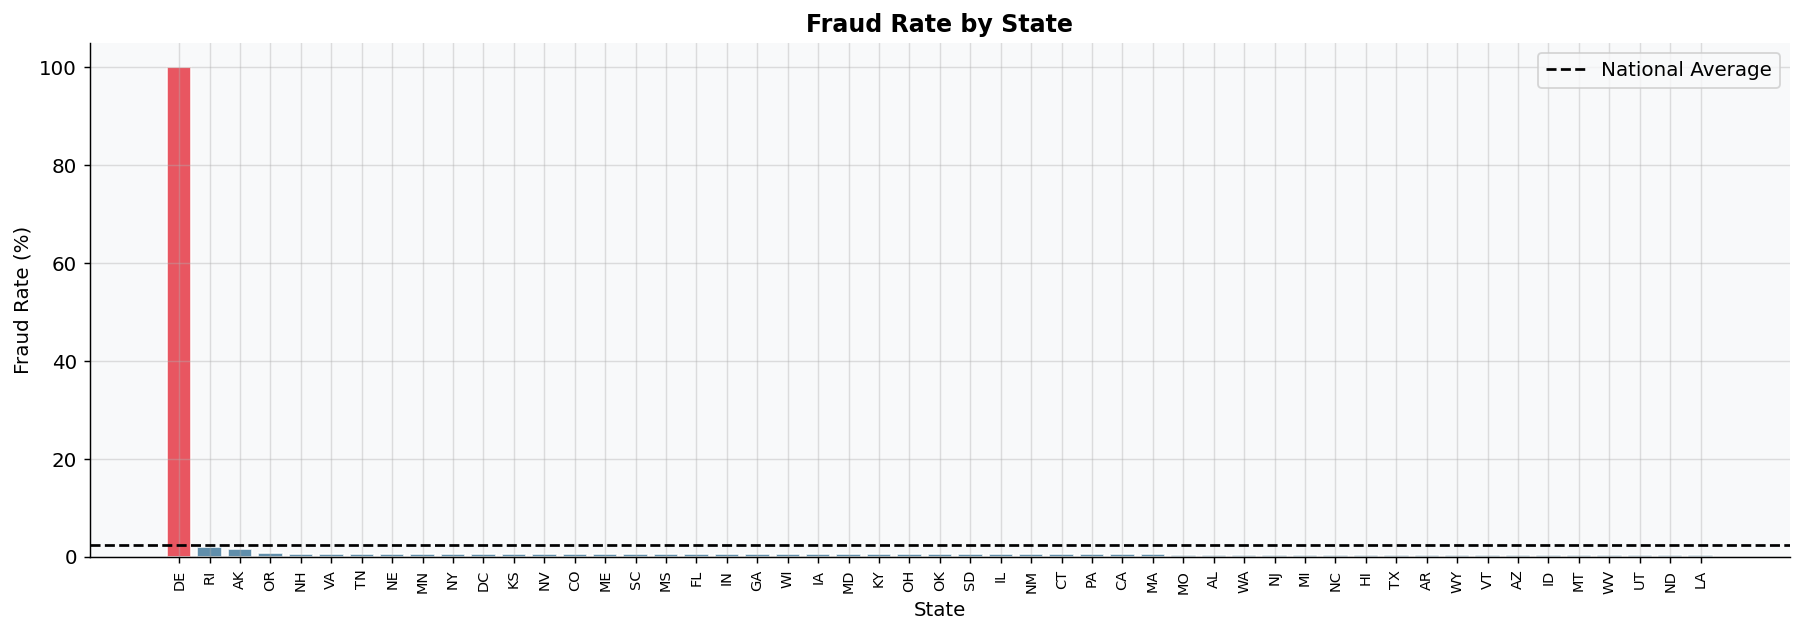

Top 10 highest fraud states:
State  FraudRate  Transactions  Frauds
   DE   1.000000             9       9
   RI   0.020134           745      15
   AK   0.016875          2963      50
   OR   0.007460         26408     197
   NH   0.006737         11727      79
   VA   0.006538         41756     273
   TN   0.006382         24913     159
   NE   0.006275         34425     216
   MN   0.006163         45433     280
   NY   0.006113        119419     730

✅ DECISION: Encode state as state_fraud_rate (target encoding on train only)


In [14]:
# ── 7b. State-level fraud heatmap ─────────────────────────────────────────
state_fraud = df.groupby('state')['is_fraud'].agg(['mean','count','sum']).reset_index()
state_fraud.columns = ['State','FraudRate','Transactions','Frauds']
state_fraud = state_fraud.sort_values('FraudRate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = [FRAUD_COLOR if r > state_fraud['FraudRate'].mean() else LEGIT_COLOR
          for r in state_fraud['FraudRate']]
ax.bar(state_fraud['State'], state_fraud['FraudRate']*100,
       color=colors, edgecolor='white', alpha=0.85)
ax.axhline(state_fraud['FraudRate'].mean()*100, color='black',
           linestyle='--', linewidth=1.5, label='National Average')
ax.set_xlabel('State')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by State', fontweight='bold')
ax.legend()
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Top 10 highest fraud states:')
print(state_fraud.head(10).to_string(index=False))
print('\n✅ DECISION: Encode state as state_fraud_rate (target encoding on train only)')

## 8. Cardholder Demographics — Who Gets Targeted?

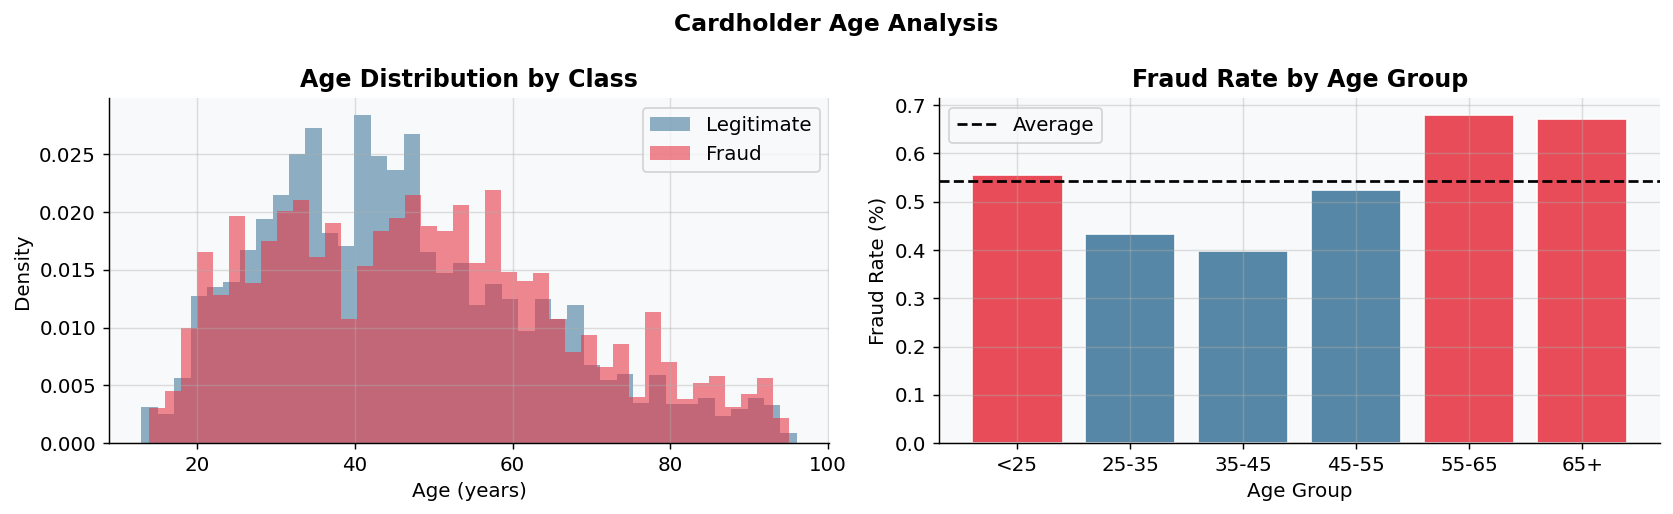

AgeBin  FraudRate  Count
   <25   0.005542 198500
 25-35   0.004336 422059
 35-45   0.003969 383483
 45-55   0.005244 352762
 55-65   0.006800 233077
   65+   0.006720 262513

✅ DECISION: Age is a usable feature — include raw Age and age_bin


In [15]:
# ── 8a. Age analysis ──────────────────────────────────────────────────────
df['age_bin'] = pd.cut(df['Age'],
    bins=[0,25,35,45,55,65,100],
    labels=['<25','25-35','35-45','45-55','55-65','65+']
)

age_stats = df.groupby('age_bin')['is_fraud'].agg(['mean','count']).reset_index()
age_stats.columns = ['AgeBin','FraudRate','Count']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Age distribution by class
for label, color, name in [(0, LEGIT_COLOR,'Legitimate'), (1, FRAUD_COLOR,'Fraud')]:
    data = df[df['is_fraud']==label]['Age']
    axes[0].hist(data.clip(0,100), bins=40, alpha=0.6, color=color,
                 label=name, density=True)
axes[0].set_title('Age Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Fraud rate by age bin
bars = axes[1].bar(age_stats['AgeBin'], age_stats['FraudRate']*100,
                   color=[FRAUD_COLOR if r > age_stats['FraudRate'].mean() else LEGIT_COLOR
                          for r in age_stats['FraudRate']],
                   edgecolor='white', alpha=0.9)
axes[1].axhline(age_stats['FraudRate'].mean()*100, color='black',
                linestyle='--', label='Average')
axes[1].set_title('Fraud Rate by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()

plt.suptitle('Cardholder Age Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(age_stats.to_string(index=False))
print('\n✅ DECISION: Age is a usable feature — include raw Age and age_bin')

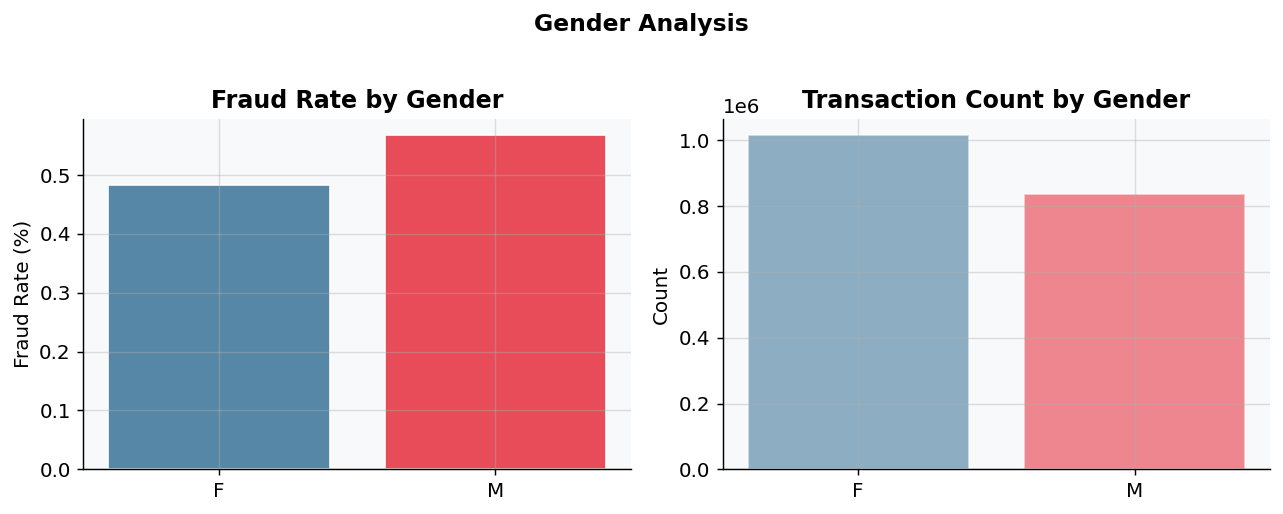

Gender  FraudRate   Total  Frauds
     F   0.004828 1014749    4899
     M   0.005673  837645    4752

⚠️  DECISION: Gender fraud rates nearly identical — low predictive value, may drop


In [16]:
# ── 8b. Gender analysis ───────────────────────────────────────────────────
gender_stats = df.groupby('gender')['is_fraud'].agg(['mean','count','sum']).reset_index()
gender_stats.columns = ['Gender','FraudRate','Total','Frauds']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(gender_stats['Gender'], gender_stats['FraudRate']*100,
            color=PALETTE[:len(gender_stats)], edgecolor='white', alpha=0.9)
axes[0].set_title('Fraud Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')

axes[1].bar(gender_stats['Gender'], gender_stats['Total'],
            color=PALETTE[:len(gender_stats)], edgecolor='white', alpha=0.6)
axes[1].set_title('Transaction Count by Gender', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Gender Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(gender_stats.to_string(index=False))

# Decision based on actual difference
if abs(gender_stats['FraudRate'].diff().iloc[-1]) < 0.001:
    print('\n⚠️  DECISION: Gender fraud rates nearly identical — low predictive value, may drop')
else:
    print('\n✅ DECISION: Gender shows meaningful fraud rate difference — encode as binary feature')

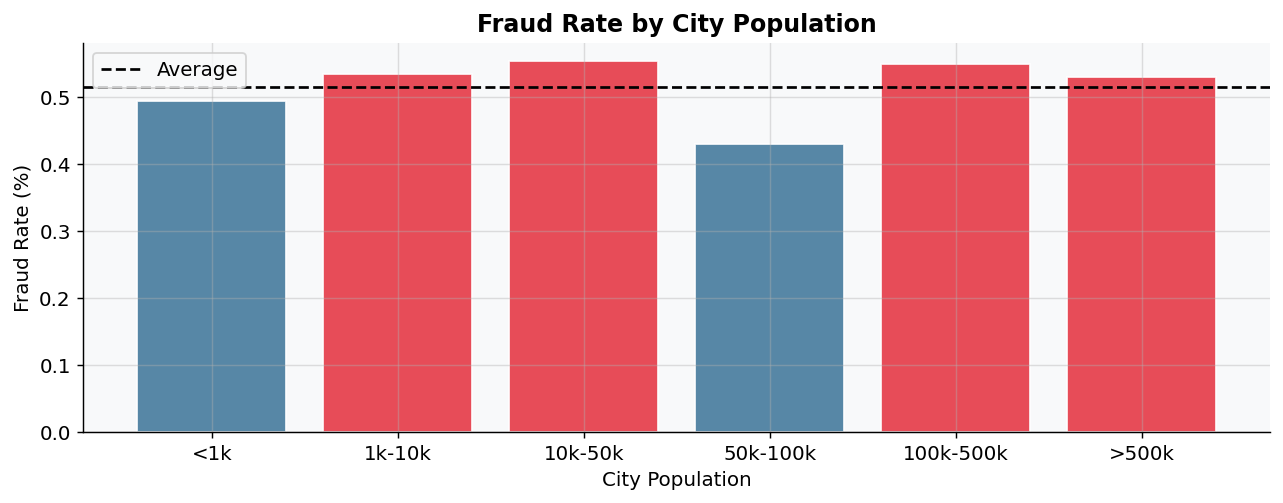

   PopBin  FraudRate  Count
      <1k   0.004949 569250
   1k-10k   0.005355 728320
  10k-50k   0.005541 208633
 50k-100k   0.004311  91401
100k-500k   0.005501 161053
    >500k   0.005313  93737

✅ DECISION: city_pop and log(city_pop) as features — rural vs urban fraud pattern


In [17]:
# ── 8c. City population analysis ─────────────────────────────────────────
df['pop_bin'] = pd.cut(df['city_pop'],
    bins=[0,1000,10000,50000,100000,500000,np.inf],
    labels=['<1k','1k-10k','10k-50k','50k-100k','100k-500k','>500k']
)

pop_stats = df.groupby('pop_bin')['is_fraud'].agg(['mean','count']).reset_index()
pop_stats.columns = ['PopBin','FraudRate','Count']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pop_stats['PopBin'], pop_stats['FraudRate']*100,
       color=[FRAUD_COLOR if r > pop_stats['FraudRate'].mean() else LEGIT_COLOR
              for r in pop_stats['FraudRate']],
       edgecolor='white', alpha=0.9)
ax.axhline(pop_stats['FraudRate'].mean()*100, color='black', linestyle='--', label='Average')
ax.set_title('Fraud Rate by City Population', fontweight='bold')
ax.set_xlabel('City Population')
ax.set_ylabel('Fraud Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(pop_stats.to_string(index=False))
print('\n✅ DECISION: city_pop and log(city_pop) as features — rural vs urban fraud pattern')

## 9. Merchant Analysis

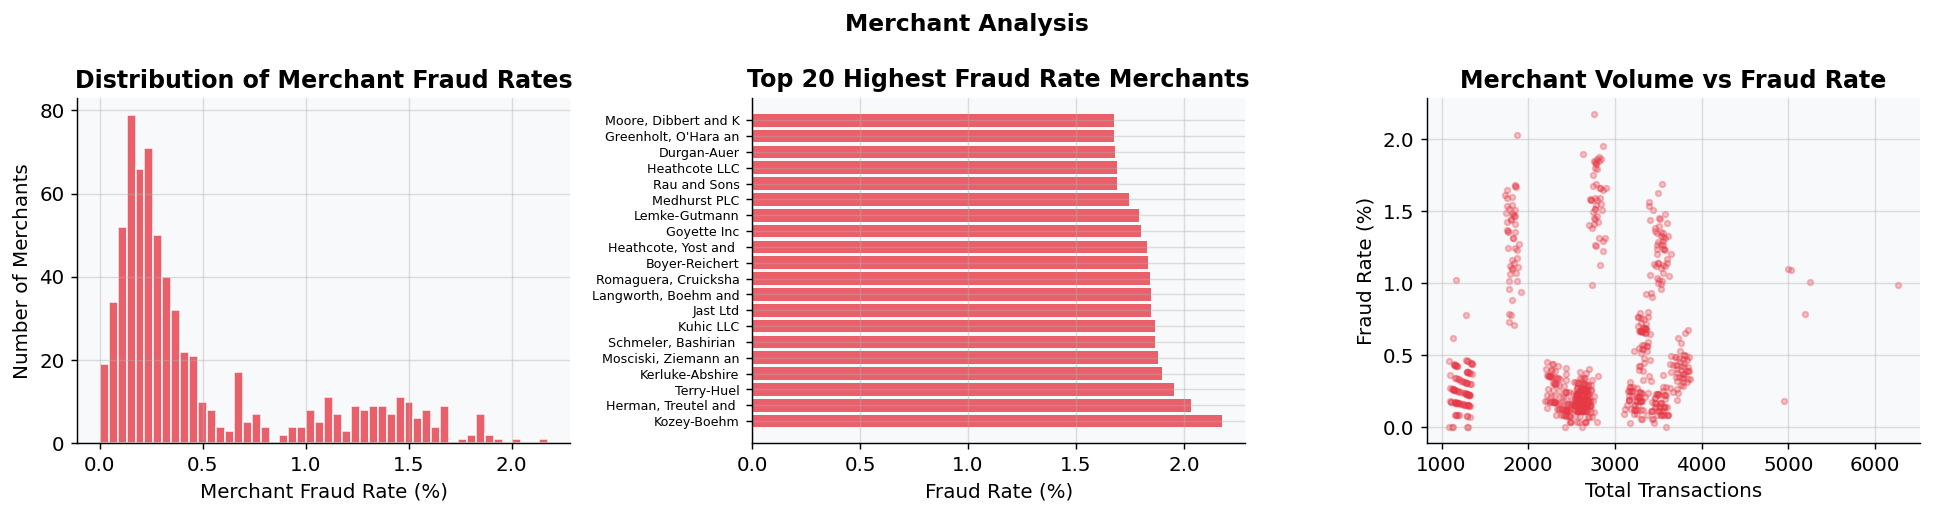

Total unique merchants : 693
Merchants with >0% fraud: 685
Merchants with 100% fraud: 0

✅ DECISION: merchant_fraud_rate via target encoding (train only) — strong feature
✅ DECISION: merchant transaction count — rare merchants may be riskier


In [18]:
# ── 9. Merchant fraud rate distribution ───────────────────────────────────
merchant_stats = df.groupby('merchant').agg(
    Total     = ('is_fraud','count'),
    Frauds    = ('is_fraud','sum'),
    FraudRate = ('is_fraud','mean'),
    AvgAmt    = ('amt','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of merchant fraud rates
axes[0].hist(merchant_stats['FraudRate']*100, bins=50,
             color=FRAUD_COLOR, alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution of Merchant Fraud Rates', fontweight='bold')
axes[0].set_xlabel('Merchant Fraud Rate (%)')
axes[0].set_ylabel('Number of Merchants')

# High fraud merchants
top_merchants = merchant_stats.nlargest(20, 'FraudRate')
axes[1].barh(range(20), top_merchants['FraudRate'].values*100,
             color=FRAUD_COLOR, alpha=0.8)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_merchants['merchant'].str.replace('fraud_','').str[:20],
                        fontsize=7)
axes[1].set_title('Top 20 Highest Fraud Rate Merchants', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')

# Merchant transaction count vs fraud rate
axes[2].scatter(merchant_stats['Total'], merchant_stats['FraudRate']*100,
                alpha=0.3, color=FRAUD_COLOR, s=10)
axes[2].set_title('Merchant Volume vs Fraud Rate', fontweight='bold')
axes[2].set_xlabel('Total Transactions')
axes[2].set_ylabel('Fraud Rate (%)')

plt.suptitle('Merchant Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total unique merchants : {merchant_stats.shape[0]:,}')
print(f'Merchants with >0% fraud: {(merchant_stats["Frauds"]>0).sum():,}')
print(f'Merchants with 100% fraud: {(merchant_stats["FraudRate"]==1).sum():,}')
print('\n✅ DECISION: merchant_fraud_rate via target encoding (train only) — strong feature')
print('✅ DECISION: merchant transaction count — rare merchants may be riskier')

## 10. Correlation & Feature Relationships

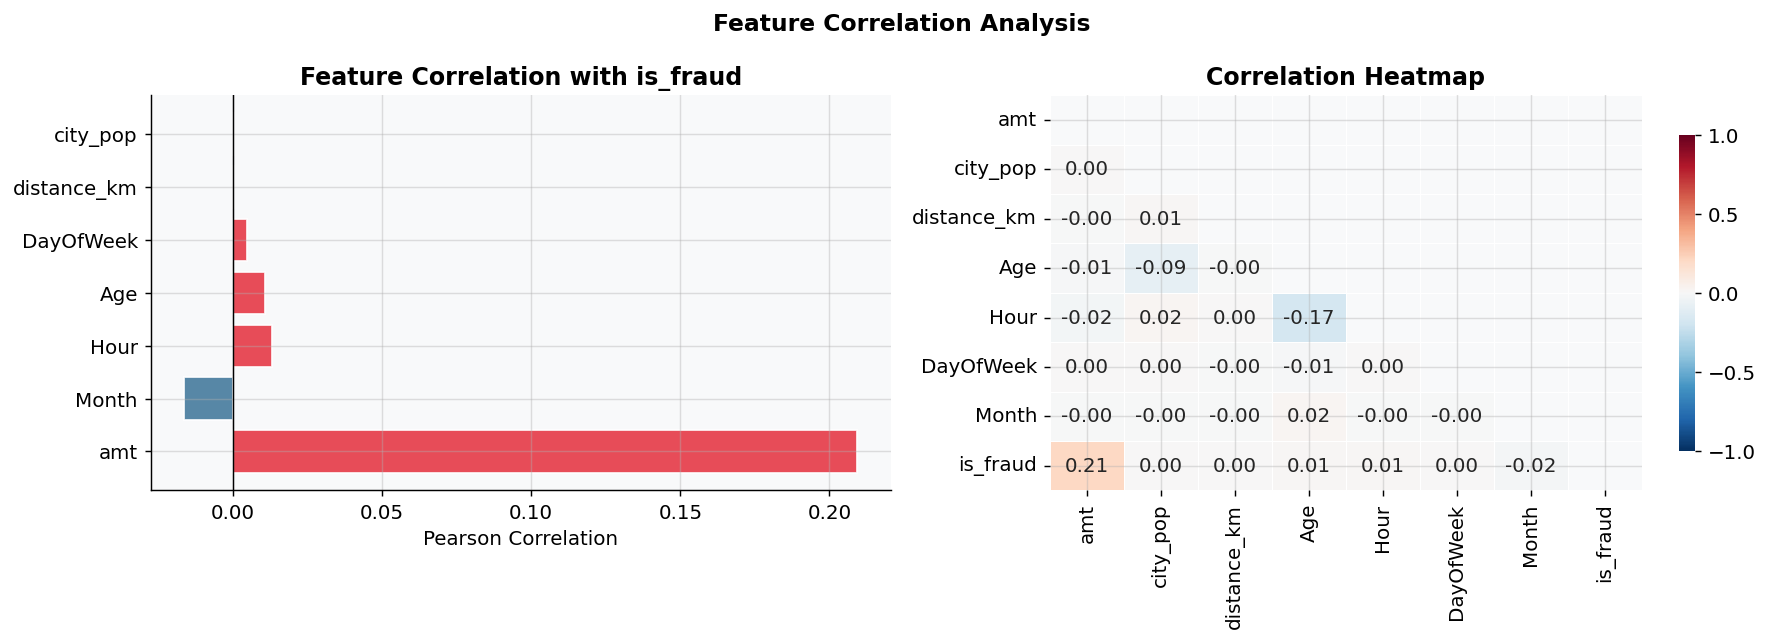

Correlations with target:
amt            0.2093
Month         -0.0164
Hour           0.0132
Age            0.0107
DayOfWeek      0.0046
distance_km    0.0004
city_pop       0.0003
Name: is_fraud, dtype: float64

✅ NOTE: Low linear correlations are expected — LightGBM captures non-linear relationships


In [19]:
# ── 10a. Correlation with target ──────────────────────────────────────────
numeric_cols = ['amt','city_pop','distance_km','Age','Hour','DayOfWeek','Month','is_fraud']
corr_with_target = df[numeric_cols].corr()['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation bar chart
colors = [FRAUD_COLOR if c > 0 else LEGIT_COLOR for c in corr_with_target.values]
axes[0].barh(corr_with_target.index, corr_with_target.values,
             color=colors, edgecolor='white', alpha=0.9)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with is_fraud', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

# Full correlation heatmap
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[1],
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, cbar_kws={'shrink':0.8}
)
axes[1].set_title('Correlation Heatmap', fontweight='bold')

plt.suptitle('Feature Correlation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlations with target:')
print(corr_with_target.round(4))
print('\n✅ NOTE: Low linear correlations are expected — LightGBM captures non-linear relationships')

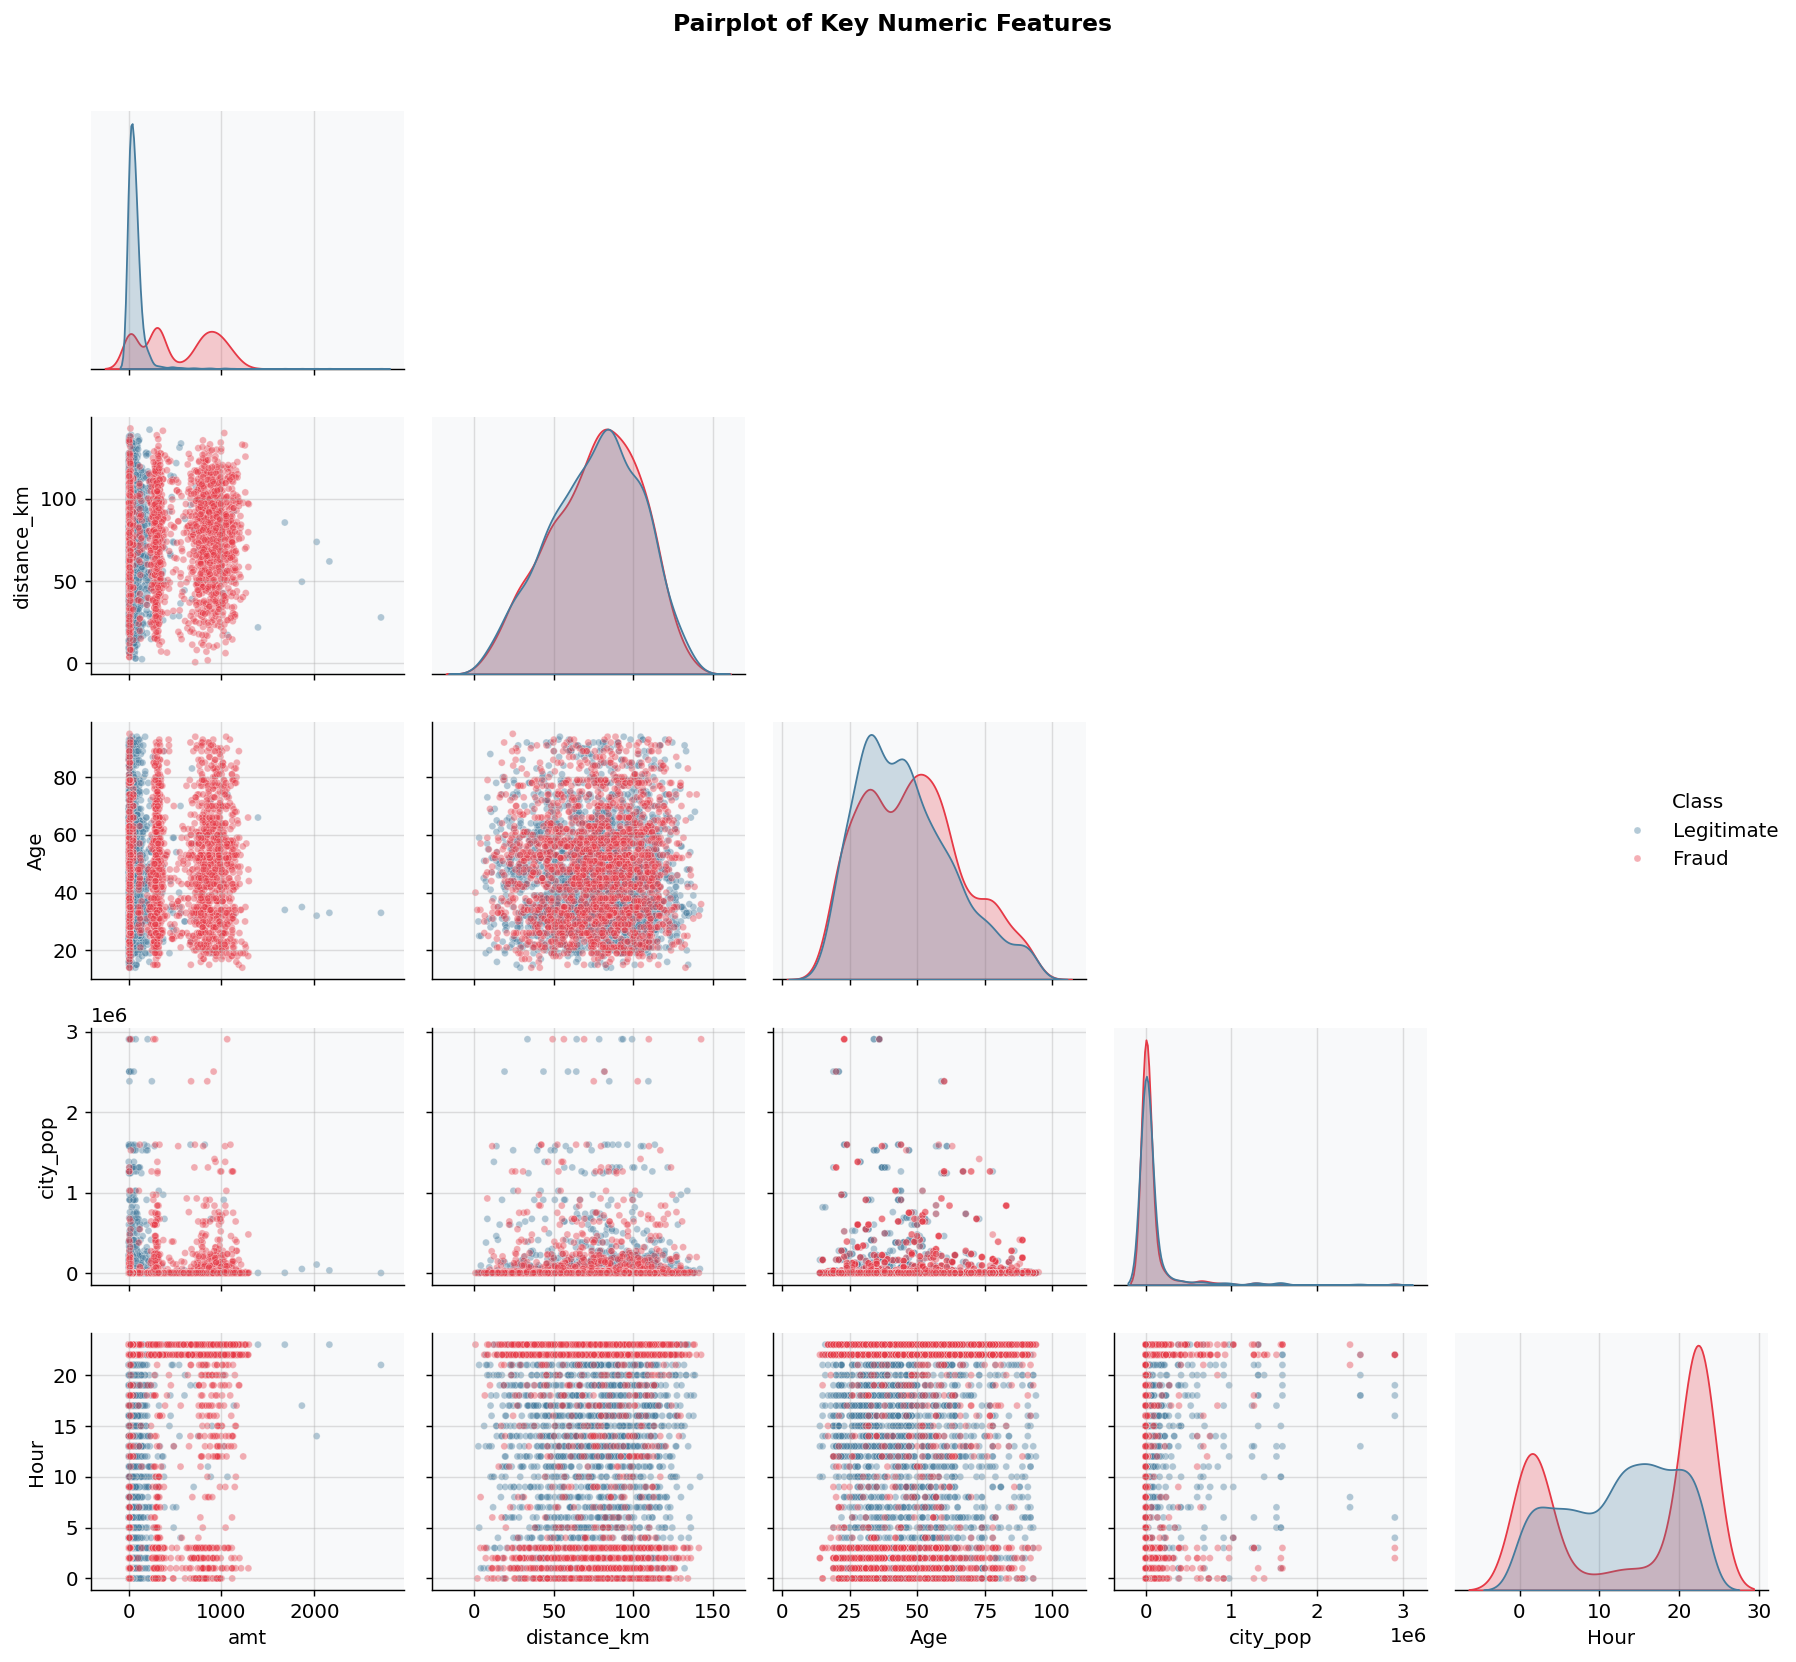

In [20]:
# ── 10b. Pairplot of top features ─────────────────────────────────────────
# Sample for speed
sample = df.groupby('is_fraud', group_keys=False).apply(
    lambda x: x.sample(min(2000, len(x)), random_state=42)
)

pp_cols = ['amt','distance_km','Age','city_pop','Hour','is_fraud']
sample['Class'] = sample['is_fraud'].map({0:'Legitimate',1:'Fraud'})

g = sns.pairplot(
    sample[pp_cols + ['Class']].rename(columns={'is_fraud':'Class_num'}),
    hue='Class',
    vars=pp_cols[:-1],
    palette={'Legitimate': LEGIT_COLOR, 'Fraud': FRAUD_COLOR},
    plot_kws={'alpha':0.4, 's':15},
    diag_kind='kde',
    corner=True,
)
g.figure.suptitle('Pairplot of Key Numeric Features', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. ✅ EDA Decisions Summary

In [21]:
# ── 11. Print all decisions ───────────────────────────────────────────────
decisions = {

    'CLASS IMBALANCE': [
        f'Fraud rate is ~{fraud_rate:.3%} → severe imbalance',
        'Use scale_pos_weight = neg/pos in LightGBM',
        'Evaluate with PR-AUC, NOT accuracy or ROC-AUC alone',
        'Do NOT random split — use time-based split on unix_time',
    ],

    'FEATURE ENGINEERING': [
        'distance_km = haversine(cardholder lat/lon, merchant lat/lon) — top signal',
        'log_distance = log1p(distance_km)',
        'Is_Far_Transaction = distance_km > threshold (use val set to tune)',
        'Age = (trans_date - dob).days // 365',
        'Hour, DayOfWeek, Month from trans_date_trans_time',
        'Is_Night = Hour in peak fraud hours found in Section 4',
        'Is_Weekend = DayOfWeek >= 5',
        'log_amt = log1p(amt)',
        'log_city_pop = log1p(city_pop)',
        'amt_vs_category_mean = amt / category average amount (train only)',
    ],

    'TARGET ENCODING (train only, then map)': [
        'category_fraud_rate — strong signal from Section 6',
        'merchant_fraud_rate — strong signal from Section 9',
        'state_fraud_rate — moderate signal from Section 7',
        'job_fraud_rate — encode if unique count is manageable',
    ],

    'FEATURES TO DROP OR DEPRIORITISE': [
        'first, last — names have no predictive value',
        'street — too granular, too many uniques',
        'trans_num — transaction ID, not a feature',
        'cc_num — raw card number leaks identity, encode as frequency instead',
        'gender — check if fraud rate difference is significant (Section 8)',
    ],

    'MODEL DECISIONS': [
        'LightGBM primary model — handles categoricals, imbalance natively',
        'XGBoost secondary — ensemble blend for +0.02–0.04 PR-AUC',
        'Time split: train on earlier unix_time, val and test on later',
        'Threshold: tune on val set using F1-optimal from PR curve',
        'No scaling needed — tree-based models are scale invariant',
        'No imputation needed — LightGBM handles NaN natively',
    ],
}

print('=' * 65)
print('  EDA DECISIONS → EXPERIMENT NOTEBOOK INPUT')
print('=' * 65)
for section, items in decisions.items():
    print(f'\n▶ {section}')
    for item in items:
        print(f'  • {item}')
print('\n' + '=' * 65)

  EDA DECISIONS → EXPERIMENT NOTEBOOK INPUT

▶ CLASS IMBALANCE
  • Fraud rate is ~0.521% → severe imbalance
  • Use scale_pos_weight = neg/pos in LightGBM
  • Evaluate with PR-AUC, NOT accuracy or ROC-AUC alone
  • Do NOT random split — use time-based split on unix_time

▶ FEATURE ENGINEERING
  • distance_km = haversine(cardholder lat/lon, merchant lat/lon) — top signal
  • log_distance = log1p(distance_km)
  • Is_Far_Transaction = distance_km > threshold (use val set to tune)
  • Age = (trans_date - dob).days // 365
  • Hour, DayOfWeek, Month from trans_date_trans_time
  • Is_Night = Hour in peak fraud hours found in Section 4
  • Is_Weekend = DayOfWeek >= 5
  • log_amt = log1p(amt)
  • log_city_pop = log1p(city_pop)
  • amt_vs_category_mean = amt / category average amount (train only)

▶ TARGET ENCODING (train only, then map)
  • category_fraud_rate — strong signal from Section 6
  • merchant_fraud_rate — strong signal from Section 9
  • state_fraud_rate — moderate signal from Sectio

In [22]:
# ── 12. Save EDA artifacts for experiment notebook ─────────────────────────
import json

# Save category fraud rates computed on full data
# (experiment notebook will recompute on train only — this is just reference)
cat_fraud_ref = df.groupby('category')['is_fraud'].mean().to_dict()
merch_fraud_ref = df.groupby('merchant')['is_fraud'].mean().to_dict()
state_fraud_ref = df.groupby('state')['is_fraud'].mean().to_dict()

eda_summary = {
    'fraud_rate':           float(fraud_rate),
    'total_rows':           int(len(df)),
    'fraud_rows':           int(df['is_fraud'].sum()),
    'category_fraud_rates': {k: round(v,5) for k,v in cat_fraud_ref.items()},
    'top_fraud_hours':      hourly.nlargest(6,'FraudRate')['Hour'].tolist(),
    'peak_fraud_hours':     hourly[hourly['FraudRate'] > hourly['FraudRate'].mean()]['Hour'].tolist(),
}

with open('eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)

print('EDA summary saved → eda_summary.json')
print('\nLoad in experiment notebook with:')
print("  import json")
print("  with open('eda_summary.json') as f: eda = json.load(f)")
print("  peak_hours = eda['peak_fraud_hours']")

EDA summary saved → eda_summary.json

Load in experiment notebook with:
  import json
  with open('eda_summary.json') as f: eda = json.load(f)
  peak_hours = eda['peak_fraud_hours']
